In [1]:
!pip install xgi --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.6 MB/s eta 0:00:00


The Comple**X** **G**roup **I**nteractions (XGI)

[Documentación](https://xgi.readthedocs.io/en/latest/api_reference.html)

# Hipergrafos

In [2]:
import xgi
import matplotlib.pyplot as plt

## Atributos

In [3]:
H = xgi.Hypergraph([[1, 2, 3], [4], [5, 6], [6, 7, 8]])
H.nodes

NodeView((1, 2, 3, 4, 5, 6, 7, 8))

In [4]:
#Cada número es el índice de una hiperenlace
H.edges

EdgeView((0, 1, 2, 3))

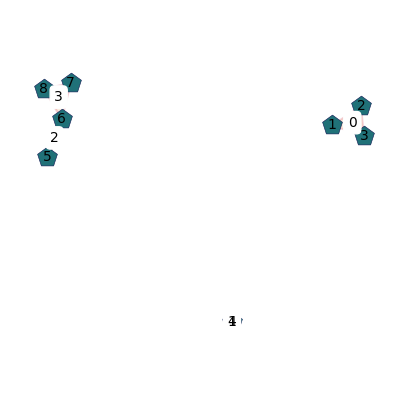

In [6]:
fig, ax = plt.subplots(figsize=(5, 5))

#layout (random_layout, pairwise_spring_layout, barycenter_spring_layout,
        #weighted_barycenter_spring_layout, circular_layout, barycenter_kamada_kawai_layout)
pos = xgi.pairwise_spring_layout(H)

xgi.draw(
    H,
    pos=pos,
    ax=ax,

    #Atributos de Nodos
    node_fc='#207178',       #Color de relleno de los nodos
    node_ec='#101652',       #Color del contorno de los nodos
    node_lw=0.4,             #Grosor del contorno de los nodos
    node_size=15,            #Tamaño de los nodos
    node_shape='p',          #Forma del nodo (o,s,D,^,p)

    #Atributos de Aristas normales
    dyad_color='black',      #Color de la línea de las aristas
    dyad_lw=3.0,             #Grosor de la línea de las aristas
    dyad_style='dashed',     #Estilo de la línea ('solid', 'dashed', 'dotted')

    #Atributos de Hiperaristas
    edge_fc='#f1c694',       #Color de relleno de la hiperarista
    edge_ec='#dc6378',       #Color del borde de la hiperarista
    edge_lw=1.5,             #Grosor del borde de la hiperarista
    alpha=0.3,               #Nivel de transparencia (0.0 a 1.0) para las áreas

    node_labels=True,        #Muestra el ID de los nodos
    hyperedge_labels=True,  #Muestra el ID de las hiperaristas
    rescale_sizes=True
)

plt.axis('off')
plt.show()

In [ ]:
#Accedemos a los nodos pertenecientes a ese hiperenlace
H.edges.members()

[{1, 2, 3}, {4}, {5, 6}, {6, 7, 8}]

In [ ]:
#El número de hiperenlaces de la HON
H.num_edges

4

In [ ]:
#El número de nodos en la HON
H.num_nodes

8

In [ ]:
#Congela una red: No permite modificarla
print(H.is_frozen)
H.freeze()
print(H.is_frozen)

False
True


## Métodos (modificar la estructura)

In [ ]:
H = xgi.Hypergraph([[1, 2, 3], [4], [5, 6], [6, 7, 8]])
#Añadir un nodo
H.add_node(9)
H.nodes

NodeView((1, 2, 3, 4, 5, 6, 7, 8, 9))

In [ ]:
#Añadir un enlace (con indice especifico)
H.add_edge([3, 4], idx='myedge')
print(H.edges)
print(H.edges.members())

[0, 1, 2, 3, 'myedge']
[{1, 2, 3}, {4}, {5, 6}, {8, 6, 7}, {3, 4}]


In [ ]:
#Añadir un nodo a un enlace ya existente
print(H.edges.members())
H.add_node_to_edge("myedge", 9)
print(H.edges)
H.edges.members()

[{1, 2, 3}, {4}, {5, 6}, {8, 6, 7}, {3, 4}]
[0, 1, 2, 3, 'myedge']


[{1, 2, 3}, {4}, {5, 6}, {6, 7, 8}, {3, 4, 9}]

In [ ]:
#Darle atributos a nodos
H.set_node_attributes(values='S', name='estado')
print(H.nodes[9])

{'estado': 'S'}


In [ ]:
#Atributos como lista
colores = {1: 'rojo', 2: 'azul', 9: 'verde'}
H.set_node_attributes(values=colores, name='color')

print(H.nodes[1]['color'])
print(H.nodes[4])

rojo
{'estado': 'S'}


In [ ]:
#Mas de un atributo a la vez por nodo
datos_completos = {
    9: {'rol': 'estudiante', 'edad': 22},
    4: {'rol': 'profesor', 'edad': 45}
}
H.set_node_attributes(values=datos_completos)
print(H.nodes[9])

{'estado': 'S', 'color': 'verde', 'rol': 'estudiante', 'edad': 22}


In [ ]:
#Añadir atributos a enlaces
H.set_edge_attributes(values="familiar", name="tipo_conexion")
print(H.edges[0])

{'tipo_conexion': 'familiar'}


In [ ]:
#Eliminar un nodo
H.remove_node(9)
H.nodes
#remove_nodes_from borra varios a la vez

NodeView((1, 2, 3, 4, 5, 6, 7, 8))

In [ ]:
#Eliminar un enlace
H.remove_edge(0) #su índice
H.edges
#remove_edges_from elimina varios a la vez

EdgeView((1, 2, 3, 'myedge'))

In [ ]:
#Hipergrafo vacío (añadir los indices de enlaces de forma mas comoda)
H_void = xgi.Hypergraph()
H_void.add_edge([3, 4], idx='myedge')
H_void.edges

EdgeView(('myedge',))

# [Complejos simpliciales](https://xgi.readthedocs.io/en/latest/api/core/xgi.core.simplicialcomplex.SimplicialComplex.html#xgi.core.simplicialcomplex.SimplicialComplex)

Un complejo simplicial es una colección de subconjuntos de un conjunto de nodos o vértices. Es un par $(V, E)$, donde $V$ es un conjunto de nodos y $E$ es un conjunto cuyos elementos son subconjuntos de $V$, es decir, cada $e \in E$ satisface $e \subset V$. Los elementos de $E$ se llaman *simplejos* o *simplices*. Adicionalmente, si un simplejo es parte de un *complejo simplicial*, todas sus caras también deben serlo. Esto hace que los complejos simpliciales sean un *caso especial de hipergrafos*.

Símplices: puntos, líneas, triángulos, pirámides

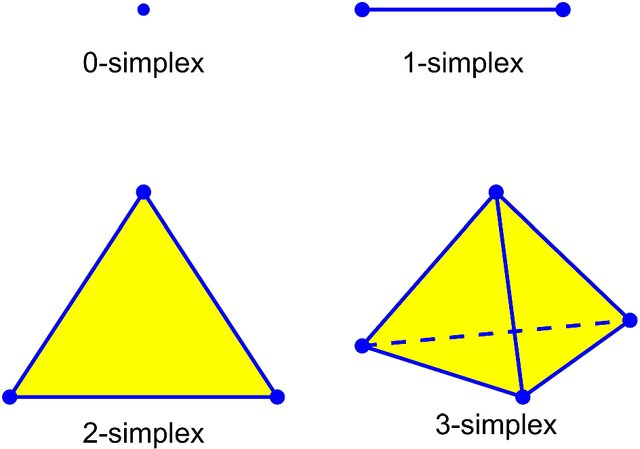

In [ ]:
#Pasamos una lista de símplices (Al pasar [1, 2, 3], xgi automáticamente creará las subcaras)
S = xgi.SimplicialComplex([[1, 2, 3], [4, 5]])

print(f"Nodos: {S.nodes}")
print(f"Símplices : {S.edges.members()}")

Nodos: [1, 2, 3, 4, 5]
Símplices : [frozenset({1, 2, 3}), frozenset({4, 5}), frozenset({2, 3}), frozenset({1, 2}), frozenset({1, 3})]


In [ ]:
H_S = xgi.SimplicialComplex([[1, 2, 3], [4], [5, 6], [6, 7, 8]])
print(f"Nodos: {H_S.nodes}")
print(f"Símplices : {H_S.edges.members()}")

Nodos: [1, 2, 3, 4, 5, 6, 7, 8]
Símplices : [frozenset({1, 2, 3}), frozenset({4}), frozenset({5, 6}), frozenset({8, 6, 7}), frozenset({1, 2}), frozenset({8, 6}), frozenset({2, 3}), frozenset({6, 7}), frozenset({1, 3}), frozenset({8, 7})]


In [ ]:
H = xgi.Hypergraph([[1, 2, 3], [4], [5, 6], [6, 7, 8]])
H.edges.members()

[{1, 2, 3}, {4}, {5, 6}, {6, 7, 8}]

In [ ]:
#Agregar nodos y simplices
#Agregar un solo nodo con atributos
S.add_node(9, color='red')

#Agregar múltiples nodos
S.add_nodes_from([10, 11])

#Agrega un símplice y TODAS sus subcaras faltantes.
#Asignarle un ID personalizado ('mi_triangulo') y atributos.
S.add_simplex([6, 7, 8], idx='mi_triangulo', weight=2.5)

S.nodes

NodeView((1, 2, 3, 4, 5, 9, 10, 11, 8, 6, 7))

In [ ]:
print(S.edges.members(), "\n"*3, S.edges)

[frozenset({1, 2, 3}), frozenset({4, 5}), frozenset({2, 3}), frozenset({1, 2}), frozenset({1, 3}), frozenset({8, 6, 7}), frozenset({8, 7}), frozenset({6, 7}), frozenset({8, 6})] 


 [0, 1, 2, 3, 4, 'mi_triangulo', 5, 6, 7]


In [ ]:
#O agregar múltiples símplices de golpe.
S.add_simplices_from([[8, 9], [9, 10]])

print(S.edges.members(), "\n"*3, S.edges)

[frozenset({1, 2, 3}), frozenset({4, 5}), frozenset({2, 3}), frozenset({1, 2}), frozenset({1, 3}), frozenset({8, 6, 7}), frozenset({8, 7}), frozenset({6, 7}), frozenset({8, 6}), frozenset({8, 9}), frozenset({9, 10})] 


 [0, 1, 2, 3, 4, 'mi_triangulo', 5, 6, 7, 8, 9]


In [ ]:
#Verificar si un grupo de nodos forma un símplice en el complejo
 #Como agregamos [6, 7, 8], la subcara [6, 7] DEBE existir.
existe = S.has_simplex([6, 7])
print(f"¿Existe el símplice [6, 7]? {existe}")

¿Existe el símplice [6, 7]? True


In [ ]:
#Forzar a que se agreguen todas las subcaras faltantes.
S.close()

In [ ]:
#Elimina un símplice por su ID.
#También elimina todos los símplices de los cuales es cara para mantener el complejo s.
S.remove_simplex_id('mi_triangulo')

S.edges

EdgeView((0, 1, 2, 3, 4, 5, 6, 7, 8, 9))

In [ ]:
#Elimina múltiples símplices
S.remove_simplex_ids_from([0, 1])

S.edges.members()

[frozenset({2, 3}),
 frozenset({1, 2}),
 frozenset({1, 3}),
 frozenset({7, 8}),
 frozenset({6, 7}),
 frozenset({6, 8}),
 frozenset({8, 9}),
 frozenset({9, 10})]

In [ ]:
#Elimina un nodo (elimina TODOS los símplices que lo contienen)
S.remove_node(9)

S.edges.members()

[frozenset({2, 3}),
 frozenset({1, 2}),
 frozenset({1, 3}),
 frozenset({7, 8}),
 frozenset({6, 7}),
 frozenset({6, 8})]

In [ ]:
# remove_nodes_from: Elimina múltiples nodos de golpe
S.remove_nodes_from([2, 7])

S.edges.members()

[frozenset({1, 3}), frozenset({6, 8})]

In [ ]:
#Verifica si el complejo está bloqueado para edición
print(f"¿Está congelado? {S.is_frozen}")
#Bloquea el complejo. Ya no se podrán agregar ni quitar nodos o símplices.
S.freeze()
print(f"¿Está congelado? {S.is_frozen}")

¿Está congelado? False
¿Está congelado? True


In [ ]:
#Elimina múltiples nodos de golpe
S.remove_nodes_from([1, 7])

S.edges.members()

XGIError: Frozen higher-order network can't be modified

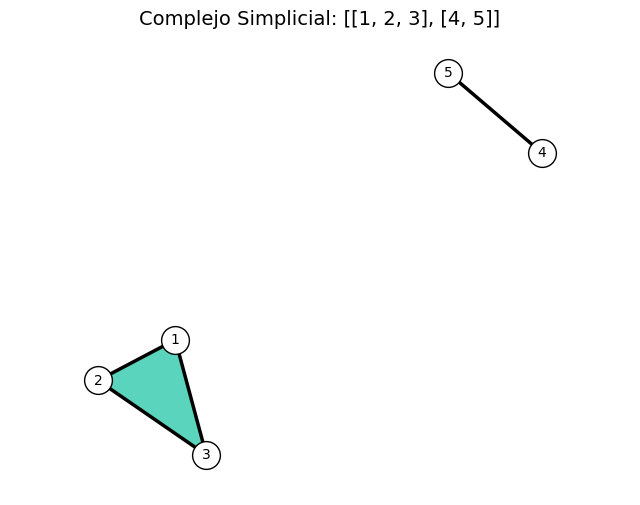

In [ ]:
S = xgi.SimplicialComplex([[1, 2, 3], [4, 5]])


plt.figure(figsize=(8, 6))
pos = xgi.barycenter_spring_layout(S)

xgi.draw(
    S,
    pos=pos,
    node_labels=True,
    node_size=20,
    node_fc='white',
    node_ec='black',
    edge_fc='#14c3a2',
    edge_ec='blue',          #Color del borde del triángulo
    alpha=0.7,               #Transparencia del relleno
    dyad_color='black',      #Color para enlaces simples
    dyad_lw=2.5
)

plt.title("Complejo Simplicial: [[1, 2, 3], [4, 5]]", fontsize=14)
plt.axis('off')
plt.show()

# Dinamicas de Sincronización

Modelo de Kuramoto

El modelo de Kuramoto es un marco matemático fundamental en el estudio de los sistemas dinámicos no lineales. Su propósito principal es describir cómo un conjunto de elementos independientes, inicialmente desordenados, puede llegar a un estado de sincronización macroscópica a través de interacciones locales.

Para comprender su mecánica, debemos definir tres componentes:

1. Osciladores

  Cada oscilador tiene un comportamiento cíclico o periódico inherente. En ausencia de influencias externas, cada elemento se moverá a su propio ritmo constante, el cual se define como su frecuencia natural.

2. Acoplamiento

  Los osciladores están interconectados a través de la topología de una red. El modelo establece que los osciladores acoplados se influyen mutuamente alterando su "fase" (su posición actual dentro del ciclo).
   
  Cada oscilador ajusta su velocidad para intentar minimizar la diferencia de fase con sus vecinos. La intensidad con la que ocurre esta atracción se rige por un parámetro global conocido como fuerza de acoplamiento $\kappa$.

3. Orden y Caos

  La evolución del sistema en el tiempo se rige por una competencia directa entre dos fuerzas opuestas:

  - La dispersión intrínseca: La tendencia de cada oscilador a seguir su propia frecuencia natural (caos).

  - La fuerza de acoplamiento: La tendencia a alinearse con los elementos conectados (orden).

Resuelve matemáticamente el modelo de Kuramoto clásico pero extendido a hipergrafos.

Separa explícitamente la fuerza de interacción en dos parámetros distintos: la influencia de las *parejas* y la influencia de *triángulos*.

Esto permite estudiar cómo las interacciones grupales aceleran o alteran la dinámica de sincronización en comparación con las redes tradicionales.

In [ ]:
import numpy as np

In [ ]:
H = xgi.random_hypergraph(20, [0.05, 0.01], seed=42)
frecuencias = np.random.normal(2.0, 0.1, 20)
fases_ini = np.random.uniform(0, 2*np.pi, 20)

fases_tiempo, tiempos = xgi.simulate_kuramoto(
    H,                  #Hipergrafo
    k2=8,             #Intensidad de atracción debido a la fase de sus vecinos
    k3=3.0,             #La influencia que ejercen los triángulos
    omega=frecuencias,  #La velocidad a la que se movería c. oscilador aislado.
    theta=fases_ini,    #Define el estado inicial de cada oscilador
    timesteps=1000,     #Cuanto tiempo evoluciona el sistema
    dt=0.01             #El tamaño del paso en el método de Euler
)

In [ ]:
fases_tiempo.shape

(1000, 20)

In [ ]:
len(tiempos)

1000

`compute_kuramoto_order_parameter` toma la matriz de datos generada por la simulación anterior (las posiciones angulares de cada nodo en cada instante de tiempo) y la comprime en un único indicador numérico.

Actúa como un termómetro de sincronía: procesa series temporales complejas y devuelve una curva que fluctúa entre cero (caos total) y uno (sincronía perfecta).

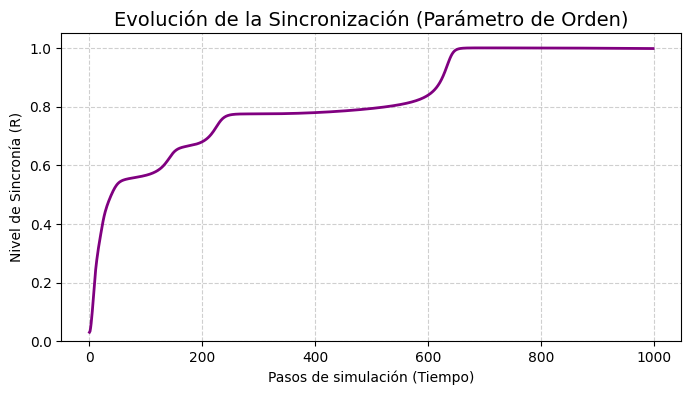

In [ ]:
parametro_orden_tiempo = xgi.compute_kuramoto_order_parameter(fases_tiempo)

plt.figure(figsize=(8, 4))

# Graficamos la línea
plt.plot(parametro_orden_tiempo, color='purple', linewidth=2)

# Añadimos formato para que sea fácil de leer
plt.title("Evolución de la Sincronización (Parámetro de Orden)", fontsize=14)
plt.xlabel("Pasos de simulación (Tiempo)")
plt.ylabel("Nivel de Sincronía (R)")

# Forzamos el límite del eje Y de 0 a 1, porque R siempre existe en ese rango
plt.ylim(0, 1.05)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

`simulate_simplicial_kuramoto` opera bajo las reglas de un complejo simplicial. Permite simular oscilaciones no solo en los nodos, sino en enlaces o estructuras de orden superior.

Calcula cómo esas oscilaciones se proyectan hacia las dimensiones geométricas inmediatamente inferiores y superiores.

In [ ]:
S = xgi.SimplicialComplex([[1, 2, 3], [3, 4, 5]])
orden_simulacion = 1 #(1 significa que oscilan las líneas/aristas)

'''2. Filtramos para saber cuántos símplices de ese orden existen y crear los arreglos'''
num_simplices = len(S.edges.filterby('order', orden_simulacion))
frecuencias_simp = np.random.normal(1.0, 0.1, (num_simplices, 1))
fases_ini_simp = np.random.uniform(0, 2*np.pi, (num_simplices, 1))

'''3. Ejecución de la simulación'''
theta, theta_menos, theta_mas = xgi.simulate_simplicial_kuramoto(
    S,                      #El complejo simplicial
    order=orden_simulacion, #La dimensión geométrica que oscila.
    omega=frecuencias_simp, #Frecuencias de los osciladores de ese orden (1).
    sigma=0.5,              #Fuerza de acoplamiento.
    theta0=fases_ini_simp,  #Distribución de las fases iniciales.
    T=5.0,                  #Tiempo total de la simulación.
    n_steps=2000            #Número de pasos o iteraciones del Método de Euler.
)

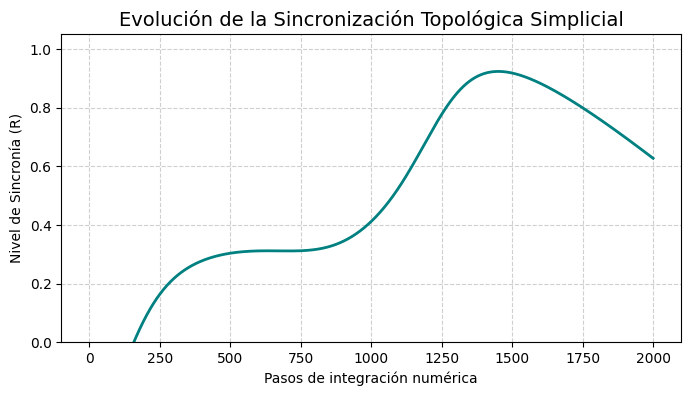

In [ ]:
R_simplicial = xgi.compute_simplicial_order_parameter(theta_menos, theta_mas)

#Graficamos el parámetro de orden
plt.figure(figsize=(8, 4))
# .flatten() por si R_simplicial es una matriz de dimensiones (1, n_steps)
plt.plot(R_simplicial.flatten(), color='teal', linewidth=2)

plt.title("Evolución de la Sincronización Topológica Simplicial", fontsize=14)
plt.xlabel("Pasos de integración numérica")
plt.ylabel("Nivel de Sincronía (R)")

plt.ylim(0, 1.05)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()